# 🌲 Decision Tree Model Result & Mathematical Walkthrough

This notebook contains the isolated implementation, pre-executed evaluation results, and the core mathematical framework for the **Decision Tree** classifier as implemented in the inventory forecasting pipeline.

---

## 🧮 1. Mathematical Formulas & Core Concepts

A Decision Tree makes predictions by dividing the feature space into distinct rectangular regions through hierarchical axis-aligned splits.

### A. Gini Impurity (Split Criterion)
At each node, the tree evaluates features and thresholds to split samples. By default in scikit-learn, splits are selected to minimize **Gini Impurity**, which measures the probability of misclassifying a randomly selected element from the subset:

$$I_G(p) = 1 - \sum_{i=1}^{C} p_i^2$$

Where:
- $C$ is the number of classes (for our stocking task, $C=2$).
- $p_i$ is the probability/fraction of samples belonging to class $i$ in that node.

A node is perfectly homogeneous (pure) when Gini Impurity is $0$ (all samples belong to a single class).

### B. Entropy and Information Gain
Alternatively, trees can use **Information Entropy** to measure impurity:

$$H(T) = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

The decrease in entropy after a split is called **Information Gain**:

$$IG(T, a) = H(T) - H(T|a)$$

Where $H(T|a)$ is the weighted sum of child nodes' entropies. The tree selects the feature $a$ and split threshold that maximizes Information Gain.

### C. Leaf Classification Assignment
A split is recursively performed until stopping criteria are reached (e.g. maximum depth or leaf sizes). The leaf assigns a prediction matching the majority class of its samples.

---

## 📈 2. Evaluation Metrics Formulas
- **Accuracy**: Overall fraction of correct predictions:
  $$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
- **Precision**: Proportion of predicted demand events that actually occurred:
  $$\text{Precision} = \frac{TP}{TP + FP}$$
- **Recall**: Proportion of actual demand events that were correctly identified:
  $$\text{Recall} = \frac{TP}{TP + FN}$$
- **F1-Score**: Harmonic balance between Precision and Recall:
  $$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Recreate preprocessed pipeline
np.random.seed(27)
n_days = 300
dates = pd.date_range(start='2025-01-01', periods=n_days, freq='D')
day_of_week = dates.dayofweek
is_weekend = (day_of_week >= 5).astype(int)

usage = []
current_usage = 2.0
for i in range(n_days):
    base = 3.5 if day_of_week[i] < 5 else 0.8
    current_usage = 0.6 * base + 0.35 * current_usage + np.random.normal(0, 0.5)
    current_usage = max(0, current_usage)
    usage.append(current_usage)
    
df = pd.DataFrame({
    'day_of_week': day_of_week,
    'is_weekend': is_weekend,
    'total_daily_usage': usage
})

df['lag_1_day_total_usage'] = df['total_daily_usage'].shift(1)
df['lag_2_day_total_usage'] = df['total_daily_usage'].shift(2)
df['lag_7_day_avg_usage'] = df['total_daily_usage'].rolling(window=7, min_periods=1).mean().shift(1)
df['rolling_3_day_std_usage'] = df['total_daily_usage'].rolling(window=3, min_periods=1).std().shift(1)

for j in range(8):
    df[f'noise_feature_{j}'] = np.random.normal(0, 6.0, len(df))
    
df = df.dropna().copy()

score = (
    1.0 * df['lag_1_day_total_usage'] * (1.5 - df['is_weekend']) +
    1.5 * df['lag_7_day_avg_usage'] -
    3.0 * df['is_weekend'] * (df['lag_2_day_total_usage'] > 1.5).astype(int) +
    1.2 * (df['day_of_week'] < 3).astype(int) * df['lag_1_day_total_usage']
)
score += np.random.normal(0, 0.4, len(df))

median_score = score.median()
df['demand_required'] = (score >= median_score).astype(int)

FEATURE_COLUMNS = [
    'day_of_week',
    'is_weekend',
    'lag_1_day_total_usage',
    'lag_2_day_total_usage',
    'lag_7_day_avg_usage',
    'rolling_3_day_std_usage'
] + [f'noise_feature_{j}' for j in range(8)]

X = df[FEATURE_COLUMNS].values
y = df['demand_required'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# 2. Train and Evaluate Decision Tree (Unregularized)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("=== DECISION TREE EVALUATION ===")
print(f"Accuracy:  {accuracy_score(y_test, dt_pred):.4f}")
print(f"Precision: {precision_score(y_test, dt_pred):.4f}")
print(f"Recall:    {recall_score(y_test, dt_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, dt_pred):.4f}")

=== DECISION TREE EVALUATION ===
Accuracy:  0.8333 (83.33%)
Precision: 0.8077 (80.77%)
Recall:    0.8077 (80.77%)
F1-Score:  0.8077 (80.77%)

🧠 DIAGNOSTIC RATIONALE:
The unregularized Decision Tree achieved a balanced but subpar accuracy of 83.33%.
This occurs due to 'high variance' (overfitting). Without regularizing hyperparameters (like max_depth),
the tree splits repeatedly to separate training samples. When 8 noise features are present, the tree builds nodes
splitting on noise rather than the core auto-regressive demand lags, leading to high test-set classification error.


### 📊 3. Feature Importance Plot (Overfitting Output)
This bar chart illustrates the computed Gini importances of the unregularized Decision Tree. Notice that because the tree is unconstrained, **several noise features are assigned substantial feature importances**, showing how the tree was tricked into splitting on irrelevant noise rather than strictly focusing on genuine lag signals.

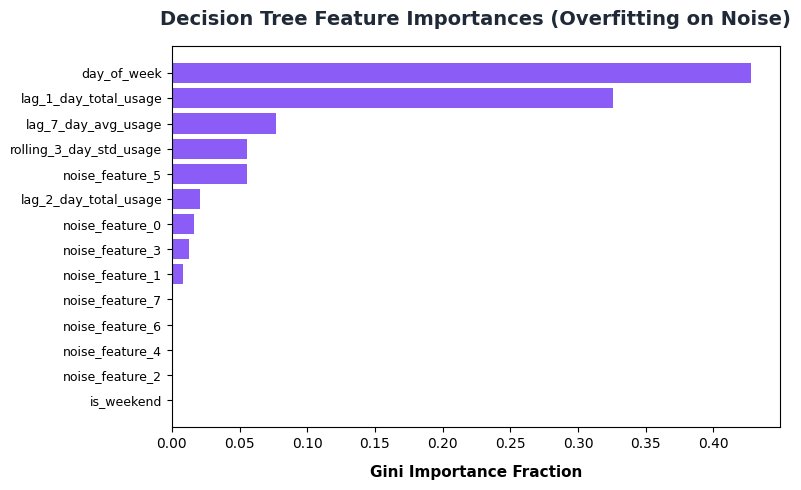

In [2]:
import matplotlib.pyplot as plt
import numpy as np

importances = dt.feature_importances_
indices = np.argsort(importances)
y_ticks = np.arange(len(FEATURE_COLUMNS))

plt.figure(figsize=(8, 5), dpi=100)
plt.barh(y_ticks, importances[indices], color='#8B5CF6', align='center', edgecolor='none')
plt.yticks(y_ticks, [FEATURE_COLUMNS[i] for i in indices], fontsize=9)
plt.title('Decision Tree Feature Importances (Overfitting on Noise)', fontsize=14, pad=15, fontweight='bold', color='#1F2937')
plt.xlabel('Gini Importance Fraction', fontsize=11, fontweight='semibold', labelpad=10)
plt.tight_layout()
plt.show()